선형 회귀 모델 -> 숫자형 타깃 변수의 크기 예측 (회귀 문제)
로지스틱 회귀 모델 -> 문자형 타깃 변수의 유형 예측 (분류 문제)

분류 모델은 2단계에 따라 타깃을 예측

1단계 : 각 클래스가 선택될(발생할) 확률을 계산
2단계 : 가장 확률이 높은 클래스를 타깃의 예측값으로 선택

즉, 모델이 직접 예측하는 값은 각 클래스가 될 확률 (클래스 자체 X)

인코딩 : 문자형 변수를 숫자 형태로 변환하는 과정

1. [one-hot encoding] : 각 클래스를 확률 형태의 숫자 벡터로 표현
    -> 클래스 수만큼 열을 만들고 타깃이 해당하는 클래스에는 1, 나머지 클래스에는 0을 표사
    즉, 문자형 변수를 더미 변수로 변환

2. [label encoding] : 각 클래스에 고유한 정숫값을 부여
    -> 구현 쉬움, 메모리 적게 사용

In [1]:
#[실습 04-01]
#one-hot encoding

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

In [2]:
#[실습 04-02]

dat = {
    '나이'    : [25,33,55],
    '스마트폰' : ['체리','망고','키위']
}

df = pd.DataFrame(dat)
df

,나이,스마트폰
0,25,체리
1,33,망고
2,55,키위


In [ ]:
#[실습 04-03]

y_oh = pd.get_dummies(df["스마트폰"]).astype(int)

print("원핫 인코딩 결과")
print(y_oh)
# 가나다순 정렬

원핫 인코딩 결과
   망고  체리  키위
0   0   1   0
1   1   0   0
2   0   0   1


In [4]:
#[실습 04-04]
#label encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_idx = le.fit_transform(df['스마트폰'])

print("라벨 인코딩 결과")
print(y_idx)

라벨 인코딩 결과
[1 0 2]


로지스틱 회귀 모델 => 클래스별 확률이 계산되는 과정

1.  각 클래스마다 가중치(w)와 편향(b)을 설정
    입력 변수가 1개인 경우 클래스마다 하나의 가중치와 편향을 사용
    w_k는 클래스 k의 가중치, b_k는 클래스 k의 편향

2.  각 클래스 k에 대해 입력 변수 X의 선형 함수로 실숫값 z_k를 계산

    z_0 = (w_0 * X) + b_0
    z_1 = (w_1 * X) + b_1
    z_2 = (w_2 * X) + b_2

이렇게 계산된 z = [z_0,z_1,z_2]는 각 클래스에 대한 score (확률 X)

3.  클래스별 점수 z_0,z_1,z_2를 Softmax 함수를 사용하여 클래스별 확률 p_0,p_1,p_2로 변환
    p_0 = e^z_0 / (e^z_0 + e^z_1 + e^z_2)
    ...
    

In [6]:
#[실습 04-05]

# 입력 변수 지정
X = df[['나이']]

# 클래스별 파라미터 지정
w = [-0.05, 0.02, 0.01]
b = [0,0,0]

# 선형변환
z0 = w[0]*X + b[0]
z1 = w[1]*X + b[1]
z2 = w[2]*X + b[2]

# 확률 계산
prob = pd.DataFrame([]) # 초기화
prob['망고'] = np.exp(z0) / (np.exp(z0)+np.exp(z1)+np.exp(z2))
prob['체리'] = np.exp(z1) / (np.exp(z0)+np.exp(z1)+np.exp(z2))
prob['키위'] = np.exp(z2) / (np.exp(z0)+np.exp(z1)+np.exp(z2))

print("클래스별 예측 확률");
prob


클래스별 예측 확률


,망고,체리,키위
0,0.088997,0.512144,0.398858
1,0.054594,0.549999,0.395407
2,0.013315,0.625692,0.360993


분류 문제에서는 모델이 예측한 클래스별 확률의 정확도 평가를 위해
Cross Entropy, CE
라는 손실 함수를 사용
:   모델이 실제 타깃 클래스의 확률을 얼마나 높게 예측했는지를 하나의 숫자로 계산
    모델이 실제 클래스의 확률을 1에 가깝게 예측할수록 CE는 작아짐
    잘못된 예측에 Penalty를 주는 손실 함수

In [8]:
#[실습 04-06]

df = pd.read_csv("브랜드선택.csv",encoding='cp949')
df

,표본_id,나이,소득,스마트폰
0,1,30,380,망고
1,2,33,290,키위
2,3,63,950,체리
3,4,24,420,망고
4,5,22,370,체리
...,...,...,...,...
195,196,43,480,키위
196,197,22,280,망고
197,198,50,730,체리
198,199,35,460,키위


In [9]:
#[실습 04-07]

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   표본_id   200 non-null    int64
 1   나이      200 non-null    int64
 2   소득      200 non-null    int64
 3   스마트폰    200 non-null    str  
dtypes: int64(3), str(1)
memory usage: 7.6 KB


In [ ]:
#[실습 04-08]

df["스마트폰"].value_counts()
# 각 클래스의 빈도 계산

스마트폰
망고    97
키위    65
체리    38
Name: count, dtype: int64

In [11]:
#[실습 04-09]

# 소비자의 평균 나이와 소득이 브랜드별로 어떻게 다른가?
df.groupby("스마트폰")[["나이","소득"]].mean()

,나이,소득
스마트폰,,
망고,27.659794,472.061856
체리,38.605263,596.315789
키위,35.615385,335.846154


<Axes: xlabel='나이', ylabel='소득'>

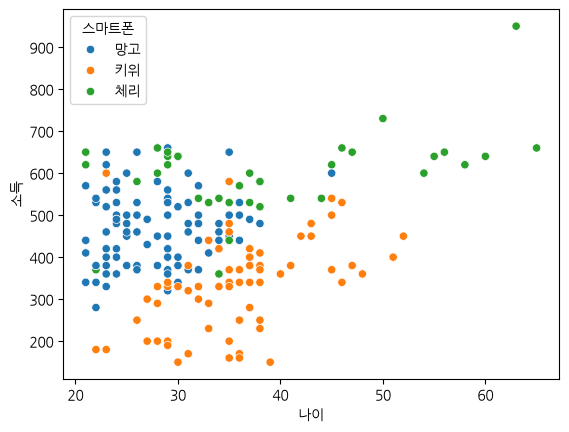

In [14]:
#[실습 04-10]

!pip install koreanize_matplotlib

import koreanize_matplotlib
import seaborn as sns

sns.scatterplot(x=df["나이"], y=df["소득"],hue=df["스마트폰"])

In [ ]:
#[실습 04-11]
#로지스틱 회귀 모델 설정과 학습

#입력과 타깃 설정
X=df[['나이','소득']]       #입력
y=df['스마트폰']            #타깃

#타깃을 라벨 인코딩 변환
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_idx = le.fit_transform(df['스마트폰'])

#모델 설정
model = LogisticRegression(max_iter=1000)
model.fit(X,y_idx)

#클래스 별 확률과 인덱스 예측
y_prob = model.predict_proba(X)     #확률 (각 데이터가 각 클래스에 속할 확률)
y_pred = model.predict(X)           #인덱스 (가장 높은 확률의 클래스만 반환)
                                    #확률                         예측
                                    #[0.628, 0.019, 0.352]   →     0
                                    #[0.058, 0.001, 0.941]   →     2
                                    #[0.000, 1.000, 0.000]   →     1
                                    #[0.963, 0.016, 0.020]   →     0     

print()
print("에측 확률")
print(np.round(y_prob[:10],3))
print()

print("예측된 클래스 인덱스")
print(y_pred[:10])


에측 확률
[[0.628 0.019 0.352]
 [0.058 0.001 0.941]
 [0.    1.    0.   ]
 [0.963 0.016 0.02 ]
 [0.963 0.005 0.032]
 [0.233 0.052 0.716]
 [0.512 0.487 0.002]
 [0.885 0.112 0.003]
 [0.735 0.262 0.003]
 [0.952 0.003 0.045]]

예측된 클래스 인덱스
[0 2 1 0 0 2 0 0 0 0]


In [17]:
#[실습 04-12]

print("예측_클래스_이름(처음 5개) :")
print(le.inverse_transform(y_pred[:5]))
print()

print("실제_클래스_이름(처음 5개) :")
print(y[:5])

예측_클래스_이름(처음 5개) :
['망고' '키위' '체리' '망고' '망고']

실제_클래스_이름(처음 5개) :
0    망고
1    키위
2    체리
3    망고
4    체리
Name: 스마트폰, dtype: str


모델 학습 -> [[예측 성능 평가]]
            회귀 : 평균제곱오차 / 결정게수
            분류 : 크로스 엔트로피 손실 / 정획도

평균 크로스 엔트로피 손실 = 0.473032399171984


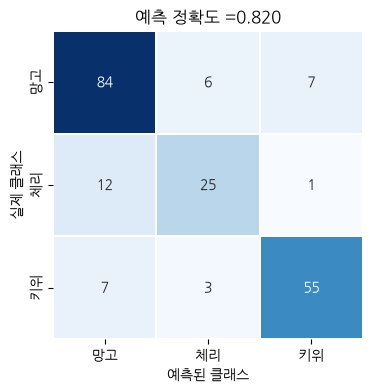

In [19]:
#[실습 04-13]
# 모델의 예측 성능을 혼동행렬(Confusion Matrix)로 시각화

from sklearn.metrics import confusion_matrix, accuracy_score

#손실 계산
loss = log_loss(y_idx, y_prob)
print("평균 크로스 엔트로피 손실 =", loss)

#혼동행렬 시각화
class_labels = ["망고", "체리","키위"]      #클래스 이름 리스트
cm = confusion_matrix(y_idx, y_pred)    #혼동행렬 계산
acc = accuracy_score(y_idx, y_pred)     #정확도 계산

plt.figure(figsize=(4,4))

sns.heatmap(cm, annot=True, linewidths=0.1, cmap='Blues', cbar=None, 
            xticklabels=class_labels, yticklabels=class_labels)

plt.title(f'예측 정확도 ={acc:.3f}')
plt.xlabel('예측된 클래스')
plt.ylabel('실제 클래스')

plt.show()

In [20]:
#[실습 04-14]
#모델이 학습을 통해 어떠한 파라미터를 찾았는가?

#파라미터 출력
print("가중치(클래스별) :")
print(model.coef_)

print("편향(클래스별) :")
print(model.intercept_)
print()

가중치(클래스별) :
[[-0.19379561  0.00329345]
 [ 0.0039767   0.01797939]
 [ 0.18981891 -0.02127284]]
편향(클래스별) :
[ 5.91479108 -9.07768452  3.16289344]



In [22]:
#[실습 04-15]
# 변수 효과 확인법 1)
#       다른 입력 변수를 고정하고 하나의 입력 변수만 변화시켜 예측 확률 변동 확인

# 나이를 30세로 고정하고 소득이 최솟값인 150만원부터 최댓값인 950만원까지 변화할 때.
# 새 브랜드의 선택 확률은 어떻게 달라지는가?

interval = np.arange(150,960,10)

X_plot = pd.DataFrame ({
    '나이' : 30,            #고정
    '소득' : interval       #구간
})

X_plot

,나이,소득
0,30,150
1,30,160
2,30,170
3,30,180
4,30,190
...,...,...
76,30,910
77,30,920
78,30,930
79,30,940


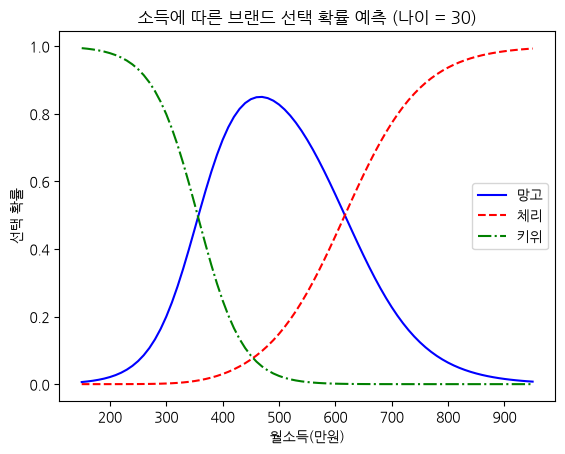

In [24]:
#[실습 04-16]
# 학습된 모델에 생성된 데이터인 X_plot을 입력해 각 브랜드가 선택될 확률을 시각화

# 확률 예측
probs = model.predict_proba(X_plot)

# 클래스 별 확률 추출
prob_0 = probs[:,0]     #망고
prob_1 = probs[:,1]     #체리
prob_2 = probs[:,2]     #키위

# 확률 시각화
plt.Figure(figsize=(8,4))
plt.plot(interval, prob_0, 'b-', label="망고")
plt.plot(interval, prob_1, 'r--', label="체리")
plt.plot(interval, prob_2, 'g-.', label="키위")
plt.xlabel("월소득(만원)")
plt.ylabel("선택 확률")
plt.legend()
plt.title("소득에 따른 브랜드 선택 확률 예측 (나이 = 30)")
plt.show()

In [ ]:
#[실습 04-17]
# 학습된 모델을 사용해 기존 데이터에 없는 입력에 대한 브랜드 선택을 예측

import warnings
warnings.filterwarnings('ignore')

x_new = [[25,550]]                              #고객 특성 변수 설정 (나이, 소득 순)
probs = model.predict_proba(x_new)              #클래스 별 확률 예측
pred_index = model.predict(x_new)               #확률이 가장 높은 클래스 인덱스
pred_brand = le.inverse_transform(pred_index)   #역함수 : 인덱스 -> 클래스 이름

print(f"이 소비자는 {np.max(probs):.3f}의 확률로 {pred_brand}를 선택할 것으로 예측됩니다.")

이 소비자는 0.877의 확률로 ['망고']를 선택할 것으로 예측됩니다.


[[0.87673475 0.12215653 0.00110872]]


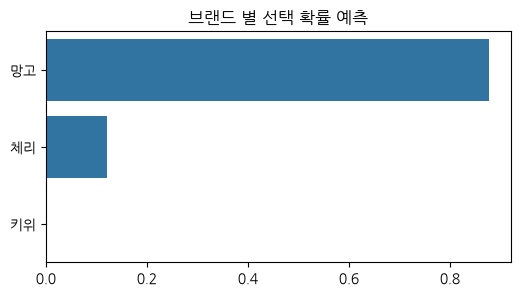

In [ ]:
#[실습 04-18]

print(probs)

plt.figure(figsize=(6,3))
sns.barplot(x=probs[0], y=class_labels)
#prob[0]으로 2차원 배열, prob을 1차원 배열로 변경
#prob = [[0.628, 0.019, 0.352]]
#prob[0] = [0.628, 0.019, 0.352]
plt.title("브랜드 별 선택 확률 예측")
plt.show()

iris.csv에는 붓꽃 150개의 특성과 품종 정보가 저장되어 있음
sepal.length : 꽃받침 길이
sepal.width : 꽃받침 너비
petal.length : 꽃잎 길이
petal.width : 꽃잎 너비
type : 붓꽃 품종 (Setosa / Versicolor / Virginica)

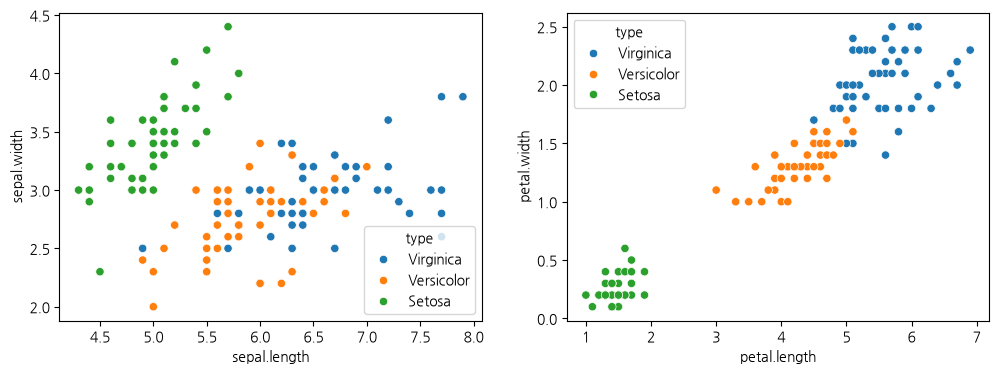

In [37]:
#되새김_4장_Q1
# 산점도를 사용하여 품종별 특성의 차이를 시각화
# 꽃받침과 꽃잎의 길이, 너비를 비교하면서 각 품종이 어떤 특징을 가지는지 살피기

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df = pd.read_csv("iris.csv",encoding='cp949')
df

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.scatterplot(x=df["sepal.length"], y=df["sepal.width"],hue=df["type"])
plt.subplot(1,2,2)
sns.scatterplot(x=df["petal.length"], y=df["petal.width"],hue=df["type"])
plt.show()

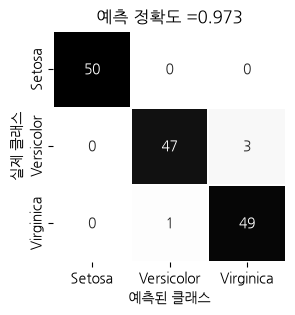

In [41]:
#되새김_4장_Q2
# type을 타깃으로, 나머지 특성 변수를 입력으로 설정하여 로지스틱 회귀 모델을 학습
# 학습이 끝나면 모델의 예측 결과와 실제 품종을 비교해 예측 성능을 시각화

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("iris.csv",encoding='cp949')

#입력과 타깃 설정
X=df[['sepal.length','sepal.width','petal.length','petal.width']]       #입력
y=df['type']                                                            #타깃

#타깃을 라벨 인코딩 변환
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_idx = le.fit_transform(df['type'])

#모델 설정
model = LogisticRegression(max_iter=1000)
model.fit(X,y_idx)

#클래스 별 확률과 인덱스 예측
y_prob = model.predict_proba(X)     #확률 (각 데이터가 각 클래스에 속할 확률)
y_pred = model.predict(X)           #인덱스 (가장 높은 확률의 클래스만 반환)  

from sklearn.metrics import confusion_matrix, accuracy_score

#손실 계산
loss = log_loss(y_idx, y_prob)

#혼동행렬 시각화
class_labels = ["Setosa", "Versicolor","Virginica"]     #클래스 이름 리스트
cm = confusion_matrix(y_idx, y_pred)                    #혼동행렬 계산
acc = accuracy_score(y_idx, y_pred)                     #정확도 계산

plt.figure(figsize=(3,3))

sns.heatmap(cm, annot=True, linewidths=0.1, cmap='Greys', cbar=False, 
            xticklabels=class_labels, yticklabels=class_labels)

plt.title(f'예측 정확도 ={acc:.3f}')
plt.xlabel('예측된 클래스')
plt.ylabel('실제 클래스')

plt.show()